In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# CSV
path = '/content/Online_Retail.csv'
sales_data = pd.read_csv(path, encoding='latin1')
sales_data.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/Online_Retail.csv'

In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
print(sales_data.describe())

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


In [ ]:
sales_data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
sales_data.duplicated().sum()

np.int64(5268)

In [ ]:
unique_values={col:sales_data[col].unique() for col in sales_data.columns }
for col, values in unique_values.items():
  print(f"Columna: {col}")
  print(f"numero de valores unicos: {len(values)}")
  print(f"valores unicos: {values[:10]}")
  print("--"*50)

Columna: InvoiceNo
numero de valores unicos: 25900
valores unicos: ['536365' '536366' '536367' '536368' '536369' '536370' '536371' '536372'
 '536373' '536374']
----------------------------------------------------------------------------------------------------
Columna: StockCode
numero de valores unicos: 4070
valores unicos: ['85123A' '71053' '84406B' '84029G' '84029E' '22752' '21730' '22633'
 '22632' '84879']
----------------------------------------------------------------------------------------------------
Columna: Description
numero de valores unicos: 4224
valores unicos: ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' 'KNITTED UNION FLAG HOT WATER BOTTLE'
 'RED WOOLLY HOTTIE WHITE HEART.' 'SET 7 BABUSHKA NESTING BOXES'
 'GLASS STAR FROSTED T-LIGHT HOLDER' 'HAND WARMER UNION JACK'
 'HAND WARMER RED POLKA DOT' 'ASSORTED COLOUR BIRD ORNAMENT']
------------------------------------------------------------------------------------------------

In [ ]:
data_cleaned = sales_data.drop_duplicates()
data_cleaned = data_cleaned.dropna(subset=["CustomerID"])
data_cleaned.duplicated().sum()

np.int64(0)

In [ ]:
data_cleaned.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
data_cleaned["TotalAmount"] = data_cleaned["Quantity"]*data_cleaned["UnitPrice"]
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34


In [ ]:
data_cleaned["InvoiceDate"]= pd.to_datetime(data_cleaned["InvoiceDate"])
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
data_cleaned["Year"]=data_cleaned["InvoiceDate"].dt.year
data_cleaned["Semester"]=data_cleaned["Month"].apply(lambda x:1 if x<=6 else 2)
data_cleaned["Trimester"]=data_cleaned["Month"].apply(lambda x: 1 if x<=3 else (2 if x<=6 else (3 if x<=9 else 4)))
data_cleaned["Month"]=data_cleaned["InvoiceDate"].dt.month
data_cleaned["Day"]=data_cleaned["InvoiceDate"].dt.day
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Day,Semester,Trimester
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,2,4
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,2,4
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4


In [ ]:
sales_by_year = data_cleaned.groupby("Year")["TotalAmount"].sum()
sales_by_year

,TotalAmount
Year,
2010,552372.860
2011,7726146.564


In [ ]:
sales_by_semester = data_cleaned.groupby(["Year", "Semester"])["TotalAmount"].sum()
sales_by_semester

Year  Semester
2010  2            552372.860
2011  1           3166939.041
      2           4559207.523
Name: TotalAmount, dtype: float64

In [ ]:
sales_by_trimester = data_cleaned.groupby(["Year", "Trimester"])["TotalAmount"].sum()
sales_by_trimester

Year  Trimester
2010  4             552372.860
2011  1            1487842.180
      2            1679096.861
      3            2117546.643
      4            2441660.880
Name: TotalAmount, dtype: float64

In [ ]:
# Cuando la cantidad es negativa se considera una devolución
total_returns = data_cleaned[data_cleaned["Quantity"]<0].shape[0]
total_returns

8872

In [ ]:
total_non_returns = data_cleaned[data_cleaned["Quantity"]>=0].shape[0]
total_non_returns

392732

Text(0.5, 1.0, 'Porcentaje de transacciones sin devolución')

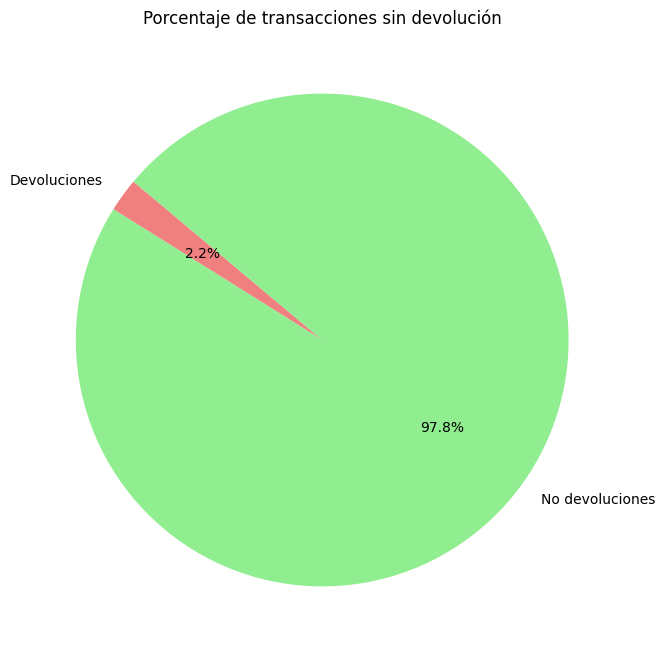

In [ ]:
# Grafico de Torta de devoluciones
import matplotlib.pyplot as plt

label = ["Devoluciones", "No devoluciones"]
sizes = [total_returns, total_non_returns]
colors = ["lightcoral", "lightgreen"]
plt.figure(figsize=(8,8))
plt.pie(sizes, labels=label,startangle=140, autopct='%1.1f%%', colors=colors)
plt.title("Porcentaje de transacciones sin devolución")

In [ ]:
# Crear una columna categorica basada en el monto total de la transaccion

def categorize_total_amount(total_amount):
  if total_amount < 20:
    return "Bajo"
  elif 20 <= total_amount < 100:
    return "Medio"
  else:
    return "Alto"

data_cleaned["TotalAmountCategory"] = data_cleaned["TotalAmount"].apply(categorize_total_amount)
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Day,Semester,Trimester,TotalAmountCategory
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,2,4,Bajo
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Medio
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,2,4,Medio
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Medio
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Medio


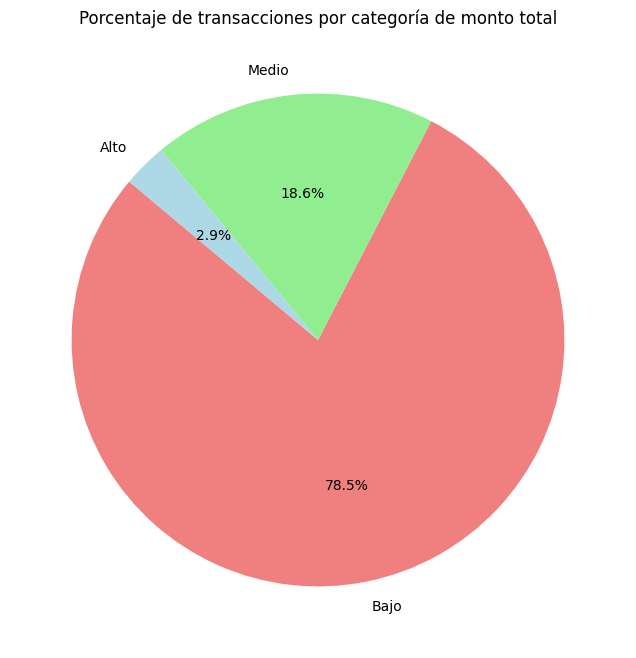

In [ ]:
# Grafico de Torta de devoluciones
import matplotlib.pyplot as plt

label = ["Bajo", "Medio", "Alto"]
# Calculate the count for each category
category_counts = data_cleaned["TotalAmountCategory"].value_counts()

# Ensure the order of sizes matches the labels.
# .get(cat, 0) handles cases where a category might not exist, returning 0 instead of erroring.
sizes = [category_counts.get(cat, 0) for cat in label]

colors = ["lightcoral", "lightgreen", "lightblue"]
plt.figure(figsize=(8,8))
plt.pie(sizes, labels=label,startangle=140, autopct='%1.1f%%', colors=colors)
plt.title("Porcentaje de transacciones por categoría de monto total")
plt.show()

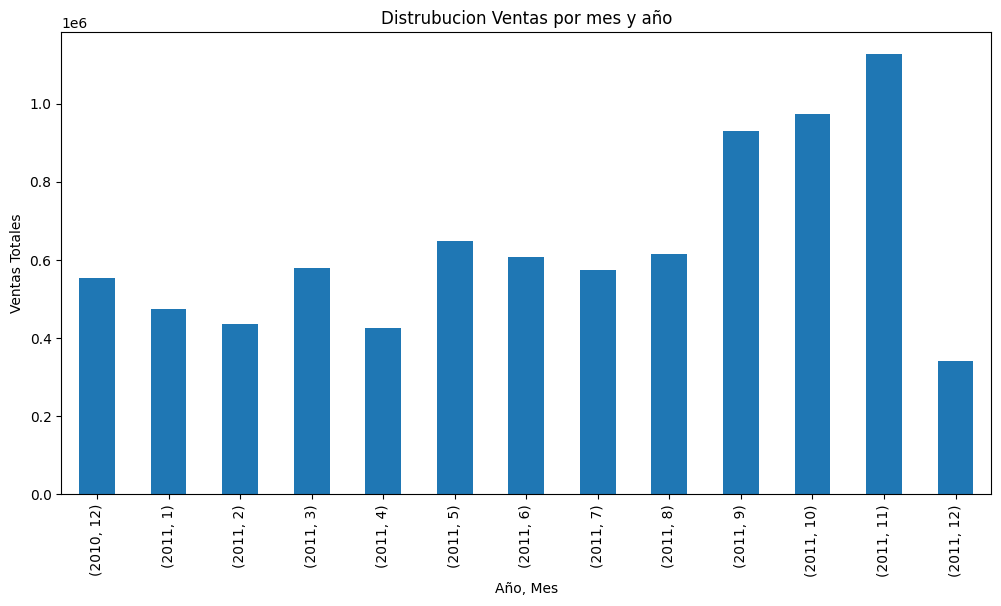

In [ ]:
plt.figure(figsize=(12, 6))
data_cleaned.groupby(["Year", "Month"])["TotalAmount"].sum().plot(kind="bar")
plt.title("Distrubucion Ventas por mes y año")
plt.xlabel("Año, Mes")
plt.ylabel("Ventas Totales")
plt.show()

In [ ]:
top_product = data_cleaned.groupby("StockCode")["Quantity"].sum().sort_values(ascending=False).head(10)
top_product = top_product.reset_index()
top_product = pd.merge(top_product, data_cleaned[["StockCode","Description"]].drop_duplicates(), on="StockCode", how="left")

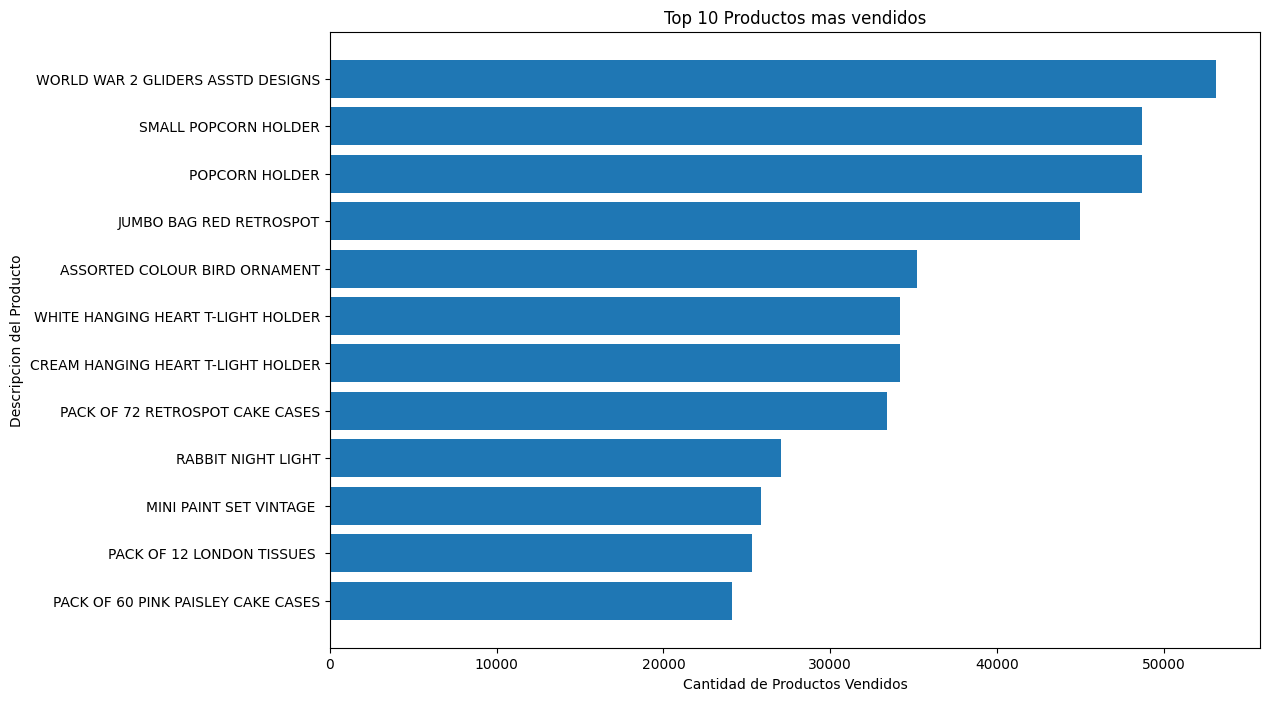

In [ ]:
plt.figure(figsize=(12,8))
plt.barh(top_product["Description"], top_product["Quantity"])
plt.xlabel("Cantidad de Productos Vendidos")
plt.ylabel("Descripcion del Producto")
plt.gca().invert_yaxis()
plt.title("Top 10 Productos mas vendidos")
plt.show()

In [ ]:
sales_data["InvoiceDate"] = pd.to_datetime(sales_data["InvoiceDate"])
sales_data.info()

/tmp/ipykernel_188/1852174240.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales_data["InvoiceDate"] = pd.to_datetime(sales_data["InvoiceDate"])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# "inplace =True" con este parametro se pide que las modificaciones se hagan sobre el archivo y no se cree copia
sales_data.dropna(subset=["InvoiceDate"], inplace =True)

In [ ]:
sales_data.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
InvoiceDate,,,,,,,
2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2.55,17850.0,United Kingdom
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6.0,3.39,17850.0,United Kingdom
2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2.75,17850.0,United Kingdom
2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,3.39,17850.0,United Kingdom
2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,3.39,17850.0,United Kingdom


In [ ]:
# Modifica los indice
sales_data.set_index("InvoiceDate")

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
InvoiceDate,,,,,,,
2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom
2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom
2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom
2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
2011-12-09 12:50:00,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France
2011-12-09 12:50:00,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France
2011-12-09 12:50:00,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France


In [ ]:
sales_data["year"] = sales_data["InvoiceDate"].dt.year
sales_data["month"] = sales_data["InvoiceDate"].dt.month
sales_data["day"] = sales_data["InvoiceDate"].dt.day
sales_data["weekday"] = sales_data["InvoiceDate"].dt.weekday
sales_data["hour"] = sales_data["InvoiceDate"].dt.hour

sales_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,month,day,weekday,hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,2,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,2,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2,8


In [ ]:
# Borrar una columna

sales_data = sales_data.drop(columns=["hour"])
sales_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,month,day,weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2


In [ ]:
sales_data["hour"] = sales_data["InvoiceDate"].dt.hour
sales_data["minute"] = sales_data["InvoiceDate"].dt.minute
sales_data["second"] = sales_data["InvoiceDate"].dt.second
sales_data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,month,day,weekday,hour,minute,second
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,2,8,26,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2,8,26,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,2,8,26,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2,8,26,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,2,8,26,0


In [ ]:
sales_data_2011 = sales_data[sales_data["year"] == 2011]
sales_data_2011.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,month,day,weekday,hour,minute,second
42481,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,2011,1,4,1,10,0,0
42482,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,2011,1,4,1,10,0,0
42483,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,2011,1,4,1,10,0,0
42484,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom,2011,1,4,1,10,0,0
42485,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom,2011,1,4,1,10,0,0
